# Combining Sample and Control Files (qc, blank, env blank) for Contamination Correction

In [1]:
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
import glob, os
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from difflib import get_close_matches



# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]

# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files    = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files   = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")

all_files = (
    [(f, "sample") for f in sample_files] +
    [(f,    "qc") for f in qc_files] +
    [(f,   "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)

rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
combined = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV
combined.to_csv(output_path, index=False)
print(f"Combined dataset saved to: {output_path}")
combined.head()

Combined dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [2]:
# Exclude compounds found in blanks,QC and env
exclude = combined.loc[
    combined['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only sample compounds 
real = combined.loc[
    (combined['FileType'] == 'sample') &
    (~combined['Compound Name'].isin(exclude))
].copy()

print("Filtered sample compounds:", real.shape)
real.head()


Filtered sample compounds: (2498, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Checking the presence of known potato aroma compounds

In [3]:
# Reference potato aroma volatiles
potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",  # fatty/green aldehydes
    "2-Heptanone", "2-Nonanone", "3-Heptanone",  # methyl ketones
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",  # fruity esters
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",  # roasted/nutty pyrazines
    "1-Heptanol", "1-Nonanol",  # long-chain alcohols
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",  # sulfur notes
    "Acetic acid", "Butanoic acid", "Hexanoic acid"  # acids (sour/cheesy)
]


# Normalize names for fuzzy matching
def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

ref_norm = { normalize(x): x for x in potato_aromas }

real['norm_name'] = real['Compound Name'].apply(normalize)
real['is_aroma'] = real['norm_name'].isin(ref_norm)

# Fuzzy match for near-misses
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~real['is_aroma']
fuzzy_hits = real.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm)))
real.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
real.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Keep only aroma compounds
aroma_samples = real[real['is_aroma']].copy()

# Group by FileName
aroma_per_sample = (
    aroma_samples
    .groupby('FileName')['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)

aroma_per_sample.head()

,FileName,Aroma Compounds
0,sample_1.csv,"[Butanal, 3-methyl-, Cyclotrisiloxane, hexamet..."
1,sample_10.csv,"[2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ..."
2,sample_11.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."
3,sample_12.csv,"[Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane..."
4,sample_13.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."


# Map variety on samples

In [4]:

# Load the combined compound file and master mapping table
combined = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv")
master = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv")
print(master.columns)
master.head()

# Filter only 'sample' rows
samples = combined[combined['FileType'] == 'sample'].copy()

# Extract sample number from filename 
samples['SampleNumber'] = samples['FileName'].str.extract(r'(\d+)').astype(int)

# Drop rows that are Blank or QC
valid_master = master[~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])].copy()

# Extract sample number from filenames 
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B')[0].astype(int)

# Extract Variety from the last part of semicolon-separated string
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Drop duplicates 
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge with compound dataset
merged = pd.merge(samples, sample_to_variety, on='SampleNumber', how='left')

# Save final mapped file
merged.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\mapped_samples_with_varieties_complete.csv", index=False)
print(" Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'")

print(f"Total rows in merged file: {len(merged)}")
print(f"Unique varieties (including NaN): {len(merged['Variety'].unique())}")
print(f"Unique mapped varieties (non-null): {merged['Variety'].nunique()}")

Index(['#', 'Filename', 'Sample', 'Block', 'Plot', 'Sample_order',
       'Sample_date', 'Rep', 'Day', 'Injection_order', 'Blender', 'Tenax',
       'Remark', 'Scan tenax', 'Check'],
      dtype='object')
 Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'
Total rows in merged file: 2498
Unique varieties (including NaN): 94
Unique mapped varieties (non-null): 94


# Use merged for aroma processing

In [5]:
# Work with merged (sample + variety)
samples = merged.copy()

# Keep only aroma compounds
samples['norm_name'] = samples['Compound Name'].apply(lambda x: x.lower().replace(' ', '').replace('-', '').replace(',', ''))
potato_aromas_norm = {x.lower().replace(' ', '').replace('-', '').replace(',', ''): x for x in [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-"
]}

samples['is_aroma'] = samples['norm_name'].isin(potato_aromas_norm)
aroma_samples = samples[samples['is_aroma']].copy()
aroma_samples['Compound Name'] = aroma_samples['norm_name'].map(potato_aromas_norm)

# Group by FileName & Variety
aroma_per_sample = (
    aroma_samples
    .groupby(['FileName', 'Variety'])['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)
aroma_per_sample.head()


,FileName,Variety,Aroma Compounds
0,sample_1.csv,ADORA,"[Butanal, 3-methyl-, Cyclotrisiloxane, hexamet..."
1,sample_10.csv,ARDECHE,"[2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ..."
2,sample_11.csv,ARGOS,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."
3,sample_12.csv,ARIZONA,"[Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane..."
4,sample_13.csv,ATLANTIC,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."


# building Variety - Compound matrix

In [6]:
# Explode for long format
exploded = aroma_per_sample.explode('Aroma Compounds').dropna(subset=['Aroma Compounds', 'Variety'])

# Build Variety × Aroma Compound matrix
variety_aroma_matrix = pd.crosstab(exploded['Variety'], exploded['Aroma Compounds'])
variety_aroma_matrix.head()

Aroma Compounds,"2-Propanone, 1-methoxy-",Benzaldehyde,"Butanal, 3-methyl-","Cyclotrisiloxane, hexamethyl-",Dimethyl trisulfide,Furfural,Hexanal,Methional,Nonanal,Pentanal
Variety,,,,,,,,,,
ADORA,0,1,1,1,0,0,0,0,1,0
AGRIA,1,1,1,1,1,0,0,0,1,1
ALOUETTE,0,1,1,1,0,0,0,0,1,0
ALTHEA,0,1,1,1,0,0,0,0,1,1
ALTURAS,0,1,1,1,0,0,1,0,1,0


# Counting aroma across each variety

In [7]:
# Count unique aroma compounds per variety
aroma_counts_by_variety = (
    variety_aroma_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Aroma Count', 'Variety': 'Variety'})
)

print("Unique aroma compounds per variety:")
print(aroma_counts_by_variety)

# Count frequency of each compound across varieties
compound_frequency = (
    variety_aroma_matrix.sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Frequency', 'Aroma Compounds': 'Compound'})
)

print("\nMost frequent aroma compounds across all varieties:")
print(compound_frequency.head(10))


Unique aroma compounds per variety:
           Variety  Aroma Count
0      LADY CLAIRE           10
1        INNOVATOR            9
2    ALVERSTONE R.            8
3           FRISIA            8
4          ARDECHE            7
..             ...          ...
85          OSPREY            3
86  MULBERRYBEAUTY            3
87           SMART            3
88          TAURUS            3
89         TRIPLE7            3

[90 rows x 2 columns]

Most frequent aroma compounds across all varieties:
                        Compound  Frequency
0                   Benzaldehyde         90
1  Cyclotrisiloxane, hexamethyl-         90
2                        Nonanal         90
3             Butanal, 3-methyl-         71
4        2-Propanone, 1-methoxy-         46
5            Dimethyl trisulfide         44
6                        Hexanal         39
7                       Pentanal         14
8                       Furfural          3
9                      Methional          2


# Barplot: Number of aroma compounds per variety

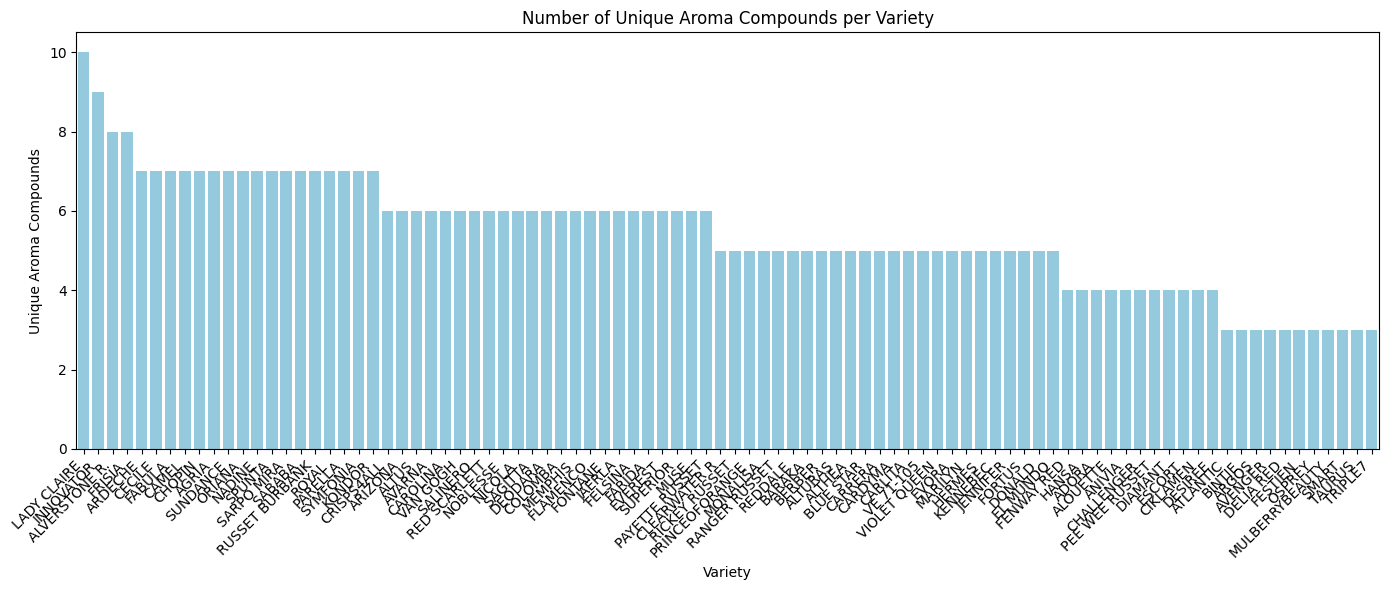

In [8]:
plt.figure(figsize=(14, 6))
sns.barplot(data=aroma_counts_by_variety, x='Variety', y='Aroma Count', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Unique Aroma Compounds per Variety")
plt.xlabel("Variety")
plt.ylabel("Unique Aroma Compounds")
plt.tight_layout()
plt.show()


# Barplot: Top 20 most common aroma compounds

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9156\1513164001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compound_frequency['Frequency'][:20], y=compound_frequency['Compound'][:20], palette='mako')


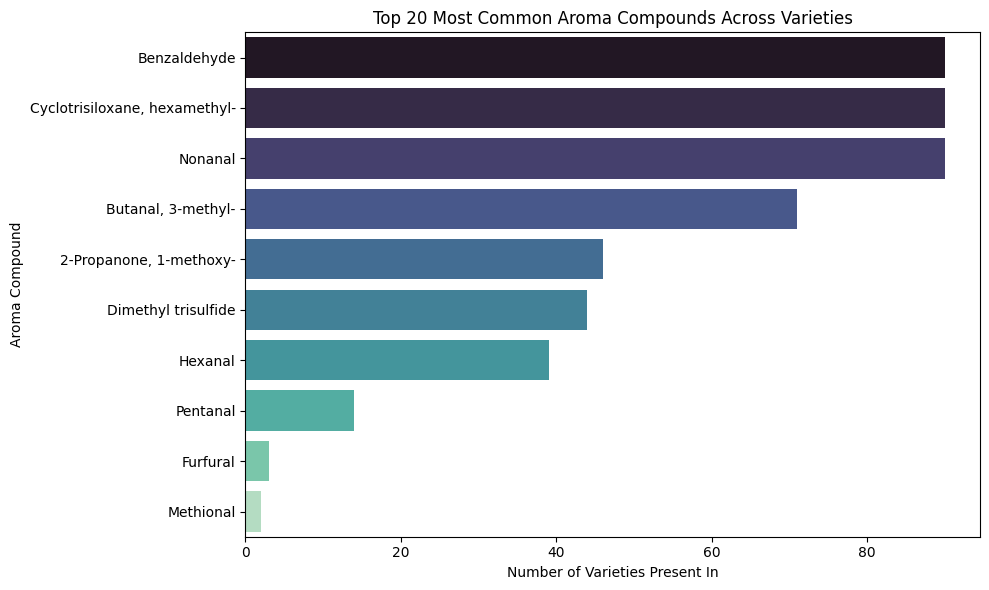

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=compound_frequency['Frequency'][:20], y=compound_frequency['Compound'][:20], palette='mako')
plt.title("Top 20 Most Common Aroma Compounds Across Varieties")
plt.xlabel("Number of Varieties Present In")
plt.ylabel("Aroma Compound")
plt.tight_layout()
plt.show()


# Heatmap: Variety vs Aroma Compound Presence

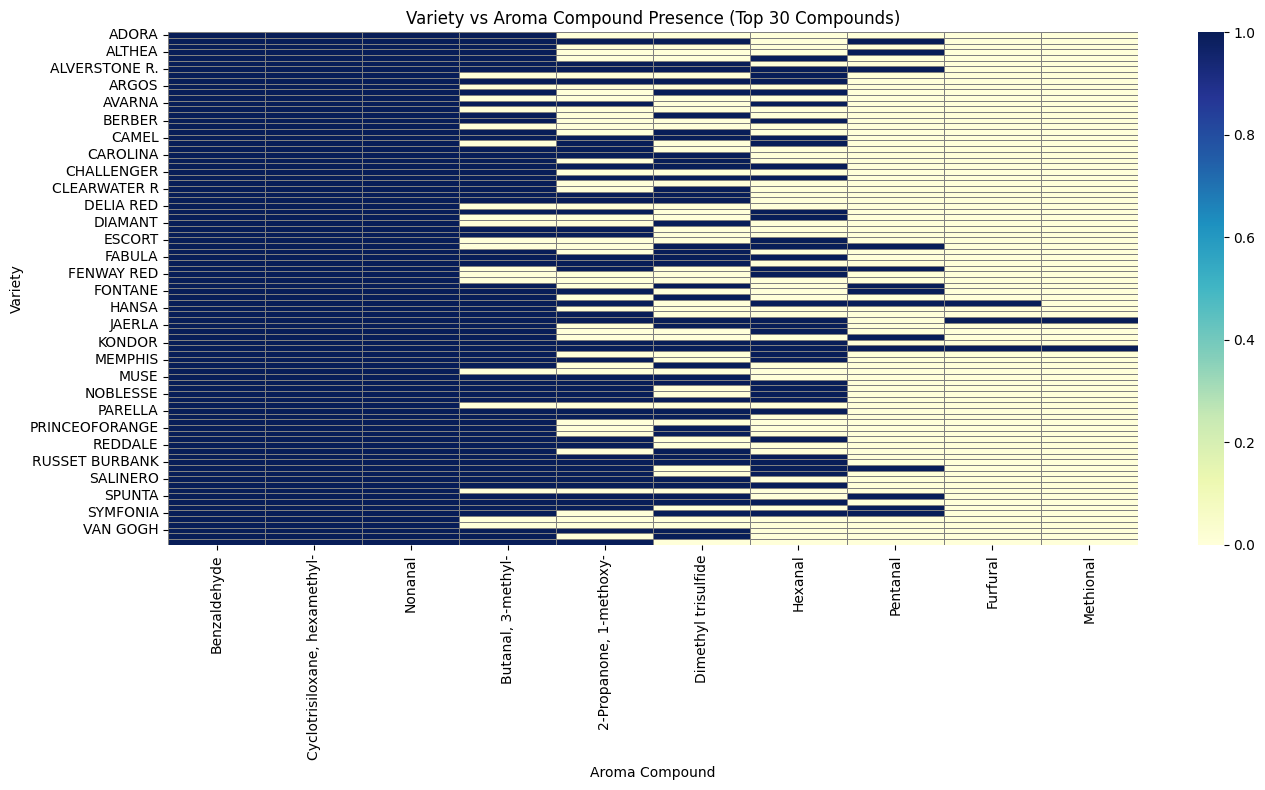

In [10]:
# Focus on top 30 compounds for readability
top30_compounds = compound_frequency['Compound'][:30]
heatmap_data = variety_aroma_matrix[top30_compounds]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Variety vs Aroma Compound Presence (Top 30 Compounds)")
plt.xlabel("Aroma Compound")
plt.ylabel("Variety")
plt.tight_layout()
plt.show()


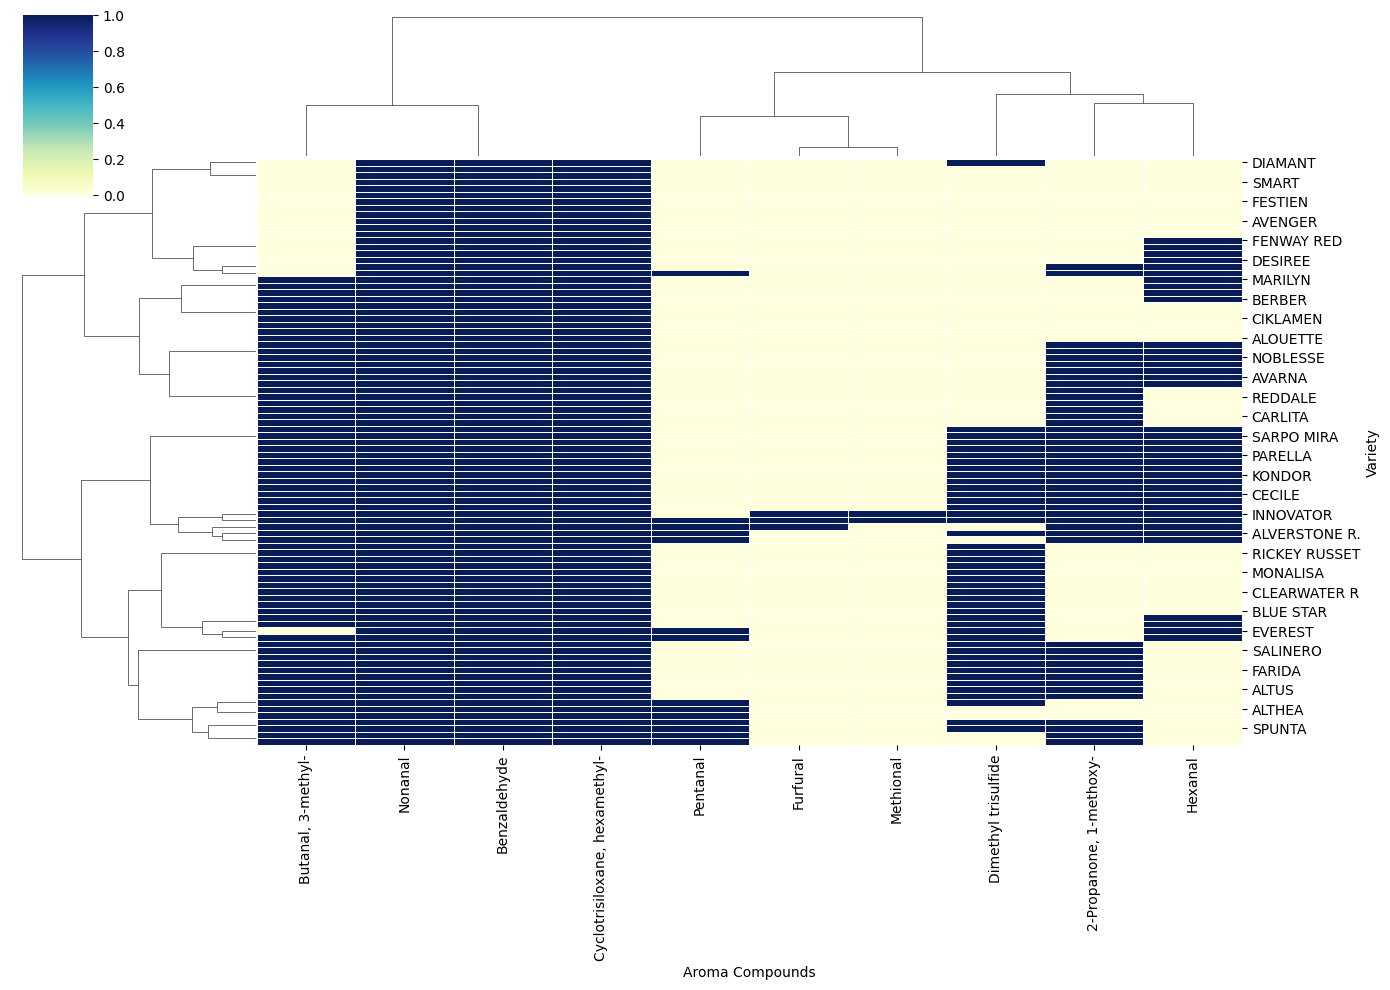

In [11]:
sns.clustermap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    figsize=(14, 10),
    method='ward',
    metric='euclidean'
)


# Compare INNOVATOR vs ALVERSTONE R   as an example to see which compounds are similar and which are diffrent

In [12]:

# Compare two varieties
variety1 = "INNOVATOR"
variety2 = "ALVERSTONE R."

compounds_variety1 = set(exploded.loc[exploded['Variety'] == variety1, 'Aroma Compounds'])
compounds_variety2 = set(exploded.loc[exploded['Variety'] == variety2, 'Aroma Compounds'])

# Find common and unique compounds
common_compounds = compounds_variety1.intersection(compounds_variety2)
unique_variety1 = compounds_variety1 - compounds_variety2
unique_variety2 = compounds_variety2 - compounds_variety1

# Create comparison table
comparison_df = pd.DataFrame({
    "Common Compounds": pd.Series(list(common_compounds)),
    f"Unique to {variety1}": pd.Series(list(unique_variety1)),
    f"Unique to {variety2}": pd.Series(list(unique_variety2))
})
print(comparison_df)

# Save to CSV
comparison_df.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Comparison_INNOVATOR_vs_ALVERSTONE.csv", index=False)
print("Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'")


                Common Compounds Unique to INNOVATOR Unique to ALVERSTONE R.
0                   Benzaldehyde            Furfural                Pentanal
1             Butanal, 3-methyl-           Methional                     NaN
2                        Nonanal                 NaN                     NaN
3        2-Propanone, 1-methoxy-                 NaN                     NaN
4                        Hexanal                 NaN                     NaN
5            Dimethyl trisulfide                 NaN                     NaN
6  Cyclotrisiloxane, hexamethyl-                 NaN                     NaN
Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'


# Jaccard Similarity Matrix for All Varieties

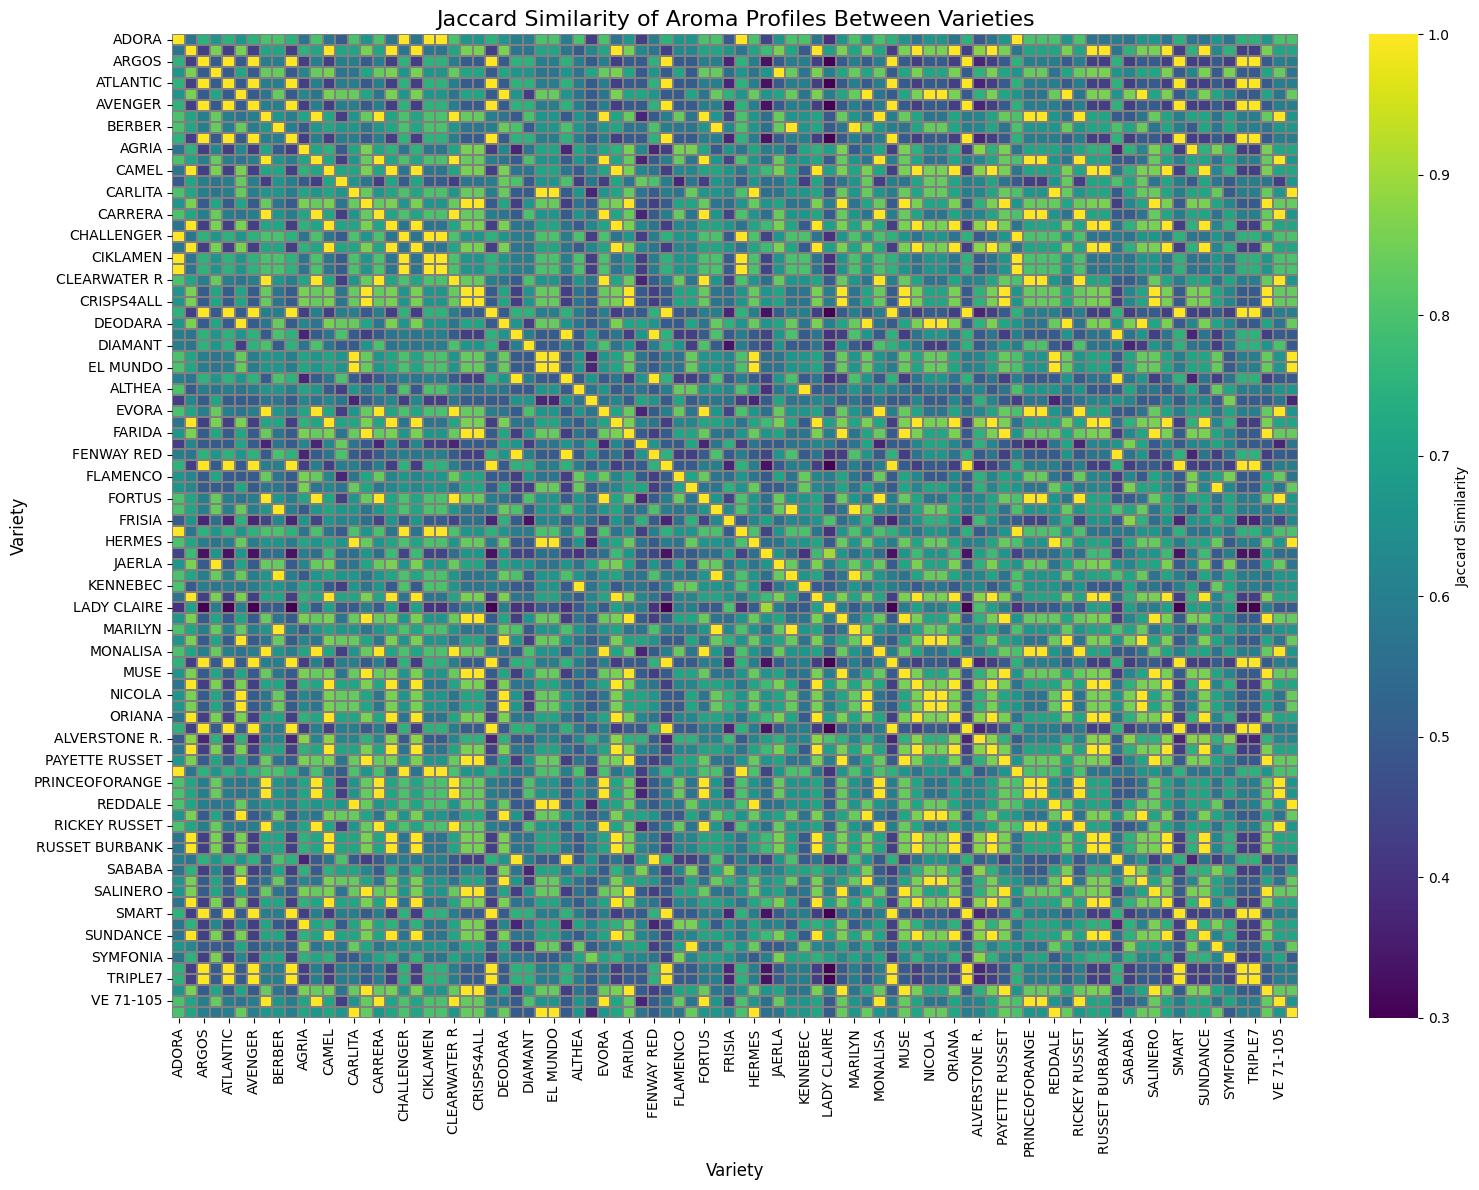

In [13]:
from itertools import combinations

# Build a dictionary: variety -> set of compounds
variety_compounds = {
    v: set(exploded.loc[exploded['Variety'] == v, 'Aroma Compounds'])
    for v in exploded['Variety'].unique()
}

# Compute Jaccard similarity for all pairs
varieties = list(variety_compounds.keys())
jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)

for v1 in varieties:
    for v2 in varieties:
        set1, set2 = variety_compounds[v1], variety_compounds[v2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard_matrix.loc[v1, v2] = intersection / union if union > 0 else 0

# Display matrix
jaccard_matrix = jaccard_matrix.fillna(0)
jaccard_matrix

plt.figure(figsize=(16,12))
sns.heatmap(
    jaccard_matrix.astype(float),
    cmap="viridis",  # Better color range
    cbar_kws={'label': 'Jaccard Similarity'},
    linewidths=0.3,
    linecolor='gray'
)
plt.title("Jaccard Similarity of Aroma Profiles Between Varieties", fontsize=16)
plt.xlabel("Variety", fontsize=12)
plt.ylabel("Variety", fontsize=12)
plt.tight_layout()
plt.show()




# Extract top 5 most similar and most different varieties


In [14]:
# Convert to long format
pairs = []
for i, v1 in enumerate(jaccard_matrix.index):
    for j, v2 in enumerate(jaccard_matrix.columns):
        if i < j:  # avoid duplicates and self-comparisons
            pairs.append((v1, v2, jaccard_matrix.loc[v1, v2]))

pairs_df = pd.DataFrame(pairs, columns=["Variety 1", "Variety 2", "Jaccard Similarity"])

# Top 5 most similar
top5_similar = pairs_df.sort_values(by="Jaccard Similarity", ascending=False).head(5)

# Top 5 most different
top5_different = pairs_df.sort_values(by="Jaccard Similarity", ascending=True).head(5)

# Combine results
top_pairs = pd.concat([
    top5_similar.assign(Type="Most Similar"),
    top5_different.assign(Type="Most Different")
])

top_pairs


,Variety 1,Variety 2,Jaccard Similarity,Type
2934,ALTURAS,MARILYN,1.0,Most Similar
2922,FORTUS,VE 71-105,1.0,Most Similar
17,ADORA,CHALLENGER,1.0,Most Similar
3082,HERMES,REDDALE,1.0,Most Similar
3036,HANSA,PEE WEE RUSSET,1.0,Most Similar
3335,LADY CLAIRE,TRIPLE7,0.3,Most Different
3334,LADY CLAIRE,TAURUS,0.3,Most Different
564,AVENGER,LADY CLAIRE,0.3,Most Different
3329,LADY CLAIRE,SMART,0.3,Most Different
3306,LADY CLAIRE,MULBERRYBEAUTY,0.3,Most Different


#  Identify Flavor-Driving Compounds  
for  flavor identification in varities we need to use sensory panel but first we should clean this dataset to remone nan values and duplicates

# Using sensory panel

In [15]:
sensory = pd.read_excel(r"C:\Users\fatemehm\Downloads\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()


Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

# using plsr to find the flavor of variaties based on sensory panel

In [16]:


# Load sensory panel data 
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()
sensory.set_index('VARIETY', inplace=True)
sensory_traits = sensory.iloc[:, 3:47].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.drop(columns=[c for c in sensory_traits.columns if "Unnamed" in str(c)], errors='ignore')
sensory_traits = sensory_traits.groupby(sensory_traits.index).mean().fillna(sensory_traits.mean())

#Align datasets 
common_varieties = sorted(set(variety_aroma_matrix.index).intersection(sensory_traits.index))
X = variety_aroma_matrix.loc[common_varieties]
Y = sensory_traits.loc[common_varieties]


#  Standardize
X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

# PLSR 
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, Y_scaled)

# Get top compounds driving flavor 
compound_importance = pd.DataFrame(pls.x_loadings_, index=X.columns, columns=['PLS1', 'PLS2'])
compound_importance['Total_Importance'] = compound_importance.abs().sum(axis=1)
top_flavor_compounds = compound_importance.sort_values('Total_Importance', ascending=False).head(20)

# Save results
top_flavor_compounds.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Top_Flavor_Driving_Compounds.csv")
print("Top flavor-driving compounds saved to 'Top_Flavor_Driving_Compounds.csv'")
top_flavor_compounds


Top flavor-driving compounds saved to 'Top_Flavor_Driving_Compounds.csv'


,PLS1,PLS2,Total_Importance
Aroma Compounds,,,
Methional,0.615850,0.281540,0.897390
Furfural,0.615850,0.281540,0.897390
Hexanal,-0.305961,0.470434,0.776395
"2-Propanone, 1-methoxy-",0.104101,0.566051,0.670152
Dimethyl trisulfide,0.279696,0.334688,0.614383
"Butanal, 3-methyl-",-0.150628,0.453664,0.604292
Pentanal,0.428071,0.007367,0.435438
Benzaldehyde,0.000000,0.000000,0.000000
"Cyclotrisiloxane, hexamethyl-",0.000000,0.000000,0.000000


The main flavor‑defining compounds for these potatoes are Methional, Furfural, Hexanal, Dimethyl trisulfide, Butanal (3‑methyl‑), and Pentanal.

# Varieties + Compounds + Sensory Attributes

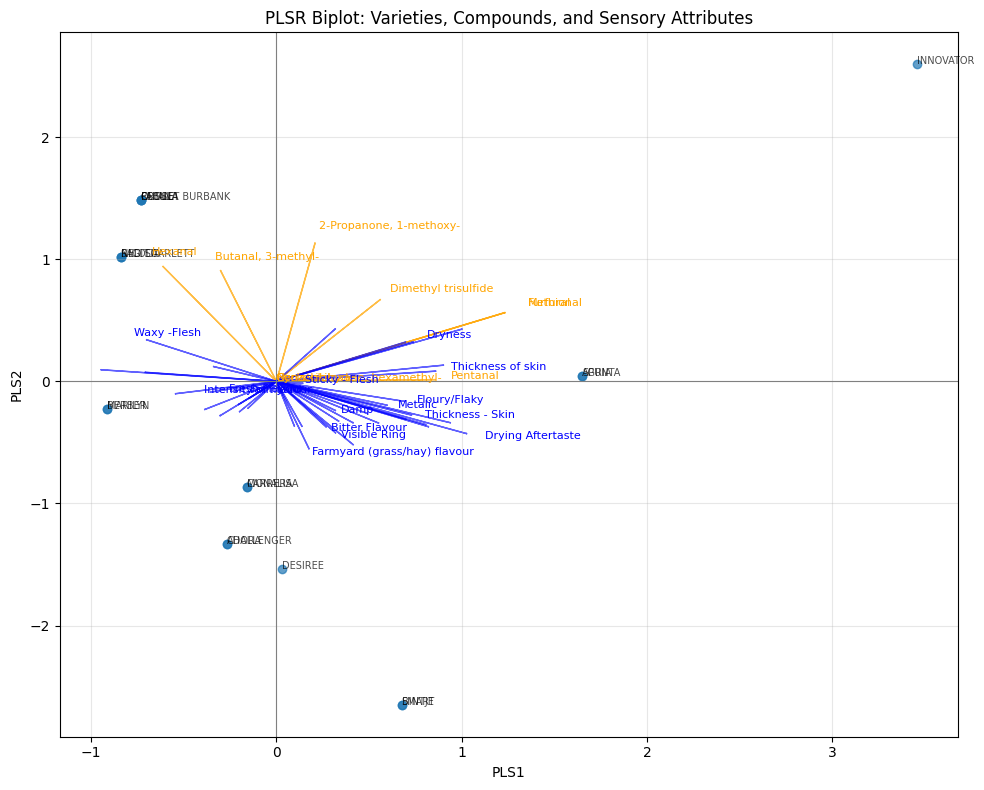

In [17]:


# Project data onto PLS components
X_scores = pls.x_scores_
Y_scores = pls.y_scores_
compounds_loadings = pls.x_loadings_
sensory_loadings = pls.y_loadings_

plt.figure(figsize=(10, 8))

# Plot varieties (scores)
plt.scatter(X_scores[:, 0], X_scores[:, 1], alpha=0.7, label="Varieties")
for i, variety in enumerate(common_varieties):
    plt.text(X_scores[i, 0], X_scores[i, 1], variety, fontsize=7, alpha=0.7)

# Plot aroma compounds (loadings)
for i, compound in enumerate(X.columns):
    plt.arrow(0, 0, compounds_loadings[i, 0]*2, compounds_loadings[i, 1]*2,
              color='orange', alpha=0.7)
    plt.text(compounds_loadings[i, 0]*2.2, compounds_loadings[i, 1]*2.2, compound,
             color='orange', fontsize=8)

# Plot sensory traits (loadings)
for i, trait in enumerate(Y.columns):
    plt.arrow(0, 0, sensory_loadings[i, 0]*2, sensory_loadings[i, 1]*2,
              color='blue', alpha=0.6)
    if i % 3 == 0:  # Reduce label clutter
        plt.text(sensory_loadings[i, 0]*2.2, sensory_loadings[i, 1]*2.2, trait,
                 color='blue', fontsize=8)

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLSR Biplot: Varieties, Compounds, and Sensory Attributes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Some varieties (like Innovator) taste sweeter and more “cooked‑like” because of Methional and Furfural.
Others (like Russet Burbank) lean toward grassy or malty flavors.
Sulfur compounds (like Dimethyl trisulfide) make some potatoes taste more savory or onion‑like.

# Heatmap (Varieties × Top Flavor Compounds)

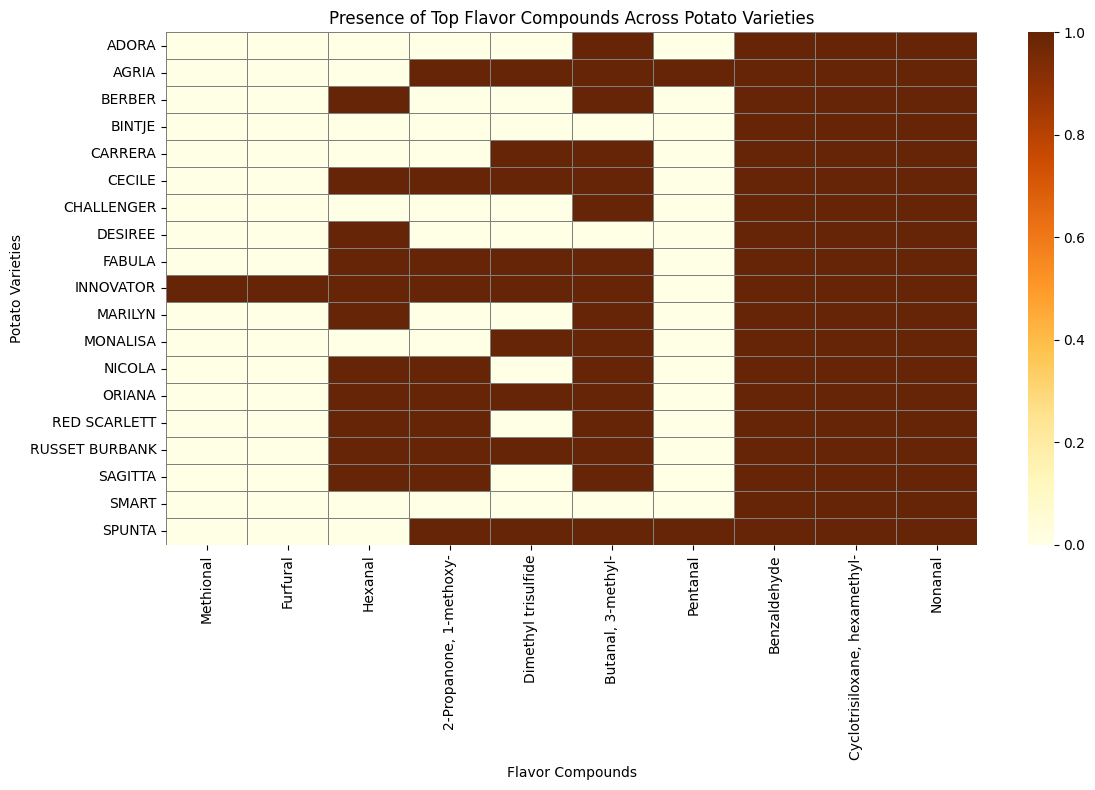

In [18]:
# Use only the top compounds we identified
top_compounds = top_flavor_compounds.index.tolist()
heatmap_data = variety_aroma_matrix[top_compounds].loc[common_varieties]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlOrBr", linewidths=0.5, linecolor='gray')
plt.title("Presence of Top Flavor Compounds Across Potato Varieties")
plt.xlabel("Flavor Compounds")
plt.ylabel("Potato Varieties")
plt.tight_layout()
plt.show()

This graph explains why different potato varieties taste different. Some are naturally sweeter and more “cooked‑potato‑like,” while others are grassy, malty, or savory

Our sensory panel covers only some varieties, but we want flavor insight for all  so we should use only the varieties with both GC–MS compounds + sensory panel scores to train the plsr model and Predict flavor for the rest(the varities that we do not have sensory information for that)

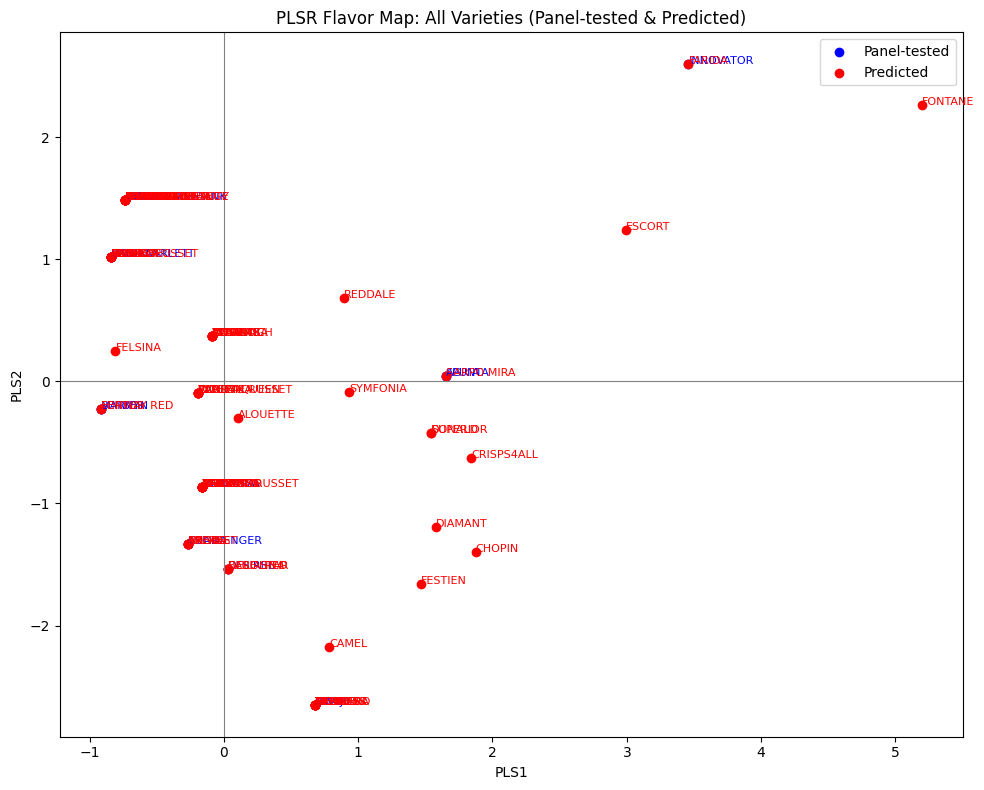

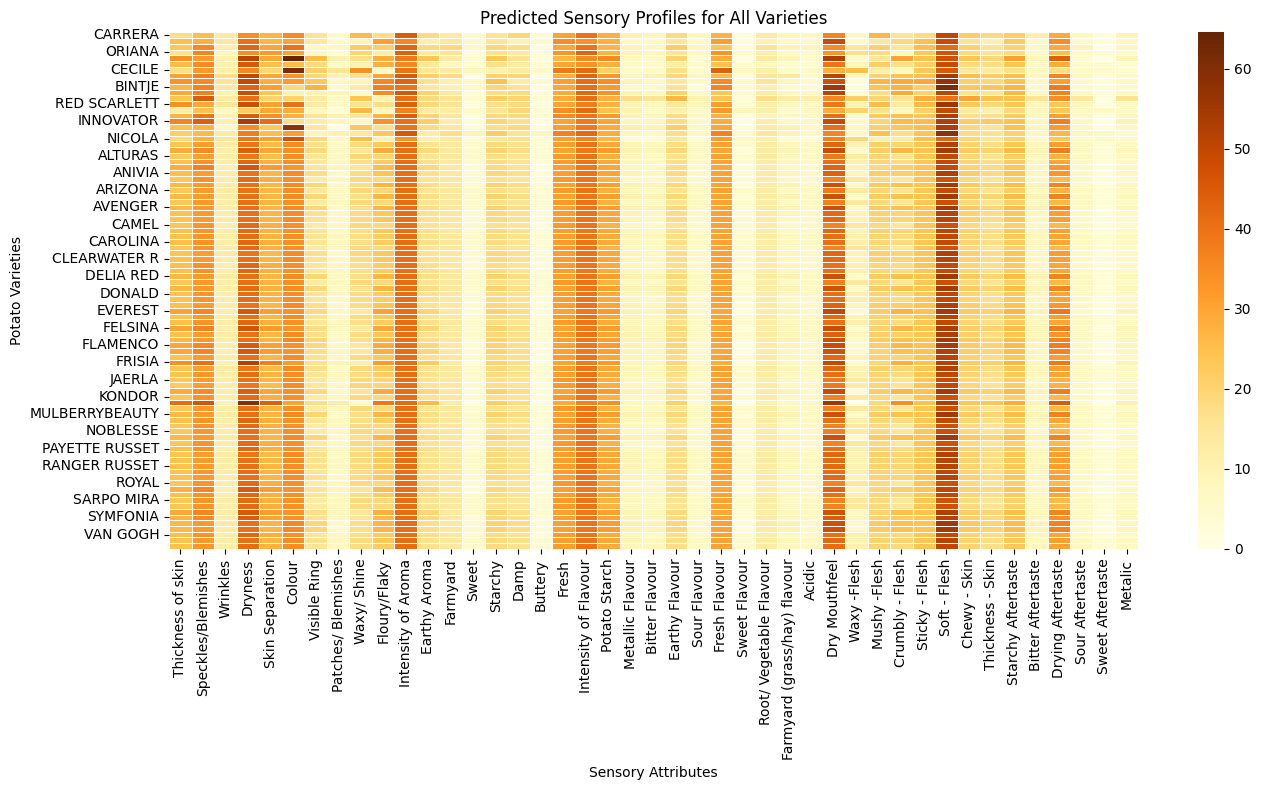

C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted sensory profiles saved as 'Predicted_Sensory_Profiles.csv'


In [19]:
X_full = variety_aroma_matrix.copy()
Y_full = sensory_traits.copy()

# Split into varieties with and without sensory data
known_varieties = list(set(X_full.index).intersection(Y_full.index))
unknown_varieties = [v for v in X_full.index if v not in Y_full.index]

X_known = X_full.loc[known_varieties]
Y_known = Y_full.loc[known_varieties]
X_unknown = X_full.loc[unknown_varieties]

#Standardize

scaler_X = StandardScaler().fit(X_known)
X_known_scaled = scaler_X.transform(X_known)
X_unknown_scaled = scaler_X.transform(X_unknown)

scaler_Y = StandardScaler().fit(Y_known)
Y_known_scaled = scaler_Y.transform(Y_known)


# Train PLSR on known varieties
pls = PLSRegression(n_components=2)
pls.fit(X_known_scaled, Y_known_scaled)


#Predict sensory for unknown varieties

Y_pred_scaled = pls.predict(X_unknown_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_pred_df = pd.DataFrame(Y_pred, index=unknown_varieties, columns=Y_known.columns)

# Merge real + predicted sensory scores
all_sensory = pd.concat([Y_known, Y_pred_df])

# Project all varieties into PLS space
X_all_scaled = scaler_X.transform(X_full)
X_scores_all = pls.transform(X_all_scaled)  # PLS scores for all varieties

# Visualization: PLSR biplot
plt.figure(figsize=(10, 8))
# Plot known (panel-tested)
plt.scatter(pls.x_scores_[:, 0], pls.x_scores_[:, 1], color='blue', label="Panel-tested")
for i, name in enumerate(known_varieties):
    plt.text(pls.x_scores_[i, 0], pls.x_scores_[i, 1], name, fontsize=8, color='blue')
# Plot unknown (predicted)
plt.scatter(X_scores_all[len(known_varieties):, 0], X_scores_all[len(known_varieties):, 1], color='red', label="Predicted")
for i, name in enumerate(unknown_varieties):
    plt.text(X_scores_all[len(known_varieties)+i, 0], X_scores_all[len(known_varieties)+i, 1], name, fontsize=8, color='red')

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLSR Flavor Map: All Varieties (Panel-tested & Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

#Heatmap of predicted sensory attributes
plt.figure(figsize=(14, 8))
sns.heatmap(all_sensory, cmap="YlOrBr", linewidths=0.5)
plt.title("Predicted Sensory Profiles for All Varieties")
plt.xlabel("Sensory Attributes")
plt.ylabel("Potato Varieties")
plt.tight_layout()
plt.show()

# Save predicted sensory data
all_sensory.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted_Sensory_Profiles.csv")
print(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted sensory profiles saved as 'Predicted_Sensory_Profiles.csv'")

Varieties near each other likely share similar flavor profiles.
for example, Innovator & Fontane are positioned far from the center it means they have strong, unique flavor characteristics (sweet/cooked potato-like).
Clusters near the center (like Russet types) indicate more balanced or milder flavors.

Also teh heatmap shows which flavor exists in each varities

We successfully used the relationship between aroma compounds and sensory data to predict the flavor profiles of all varieties. This means even varieties
that weren’t tasted by the panel can now be classified by their predicted flavor characteristics (sweet, earthy, buttery, etc.).

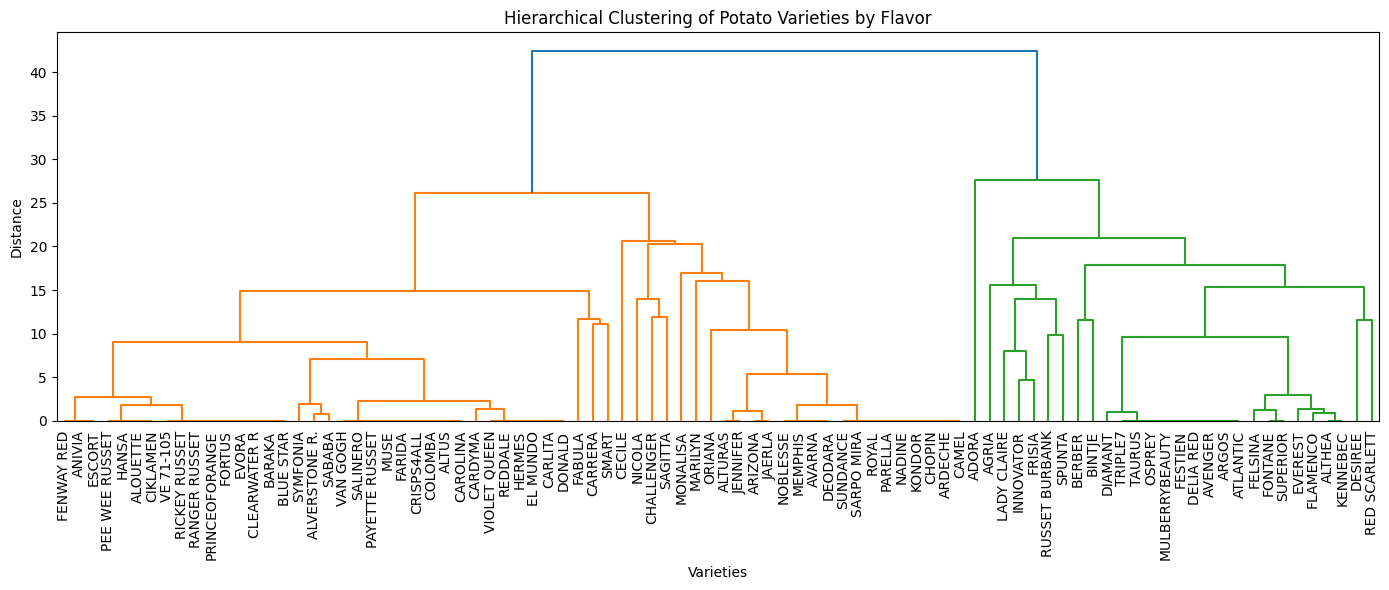

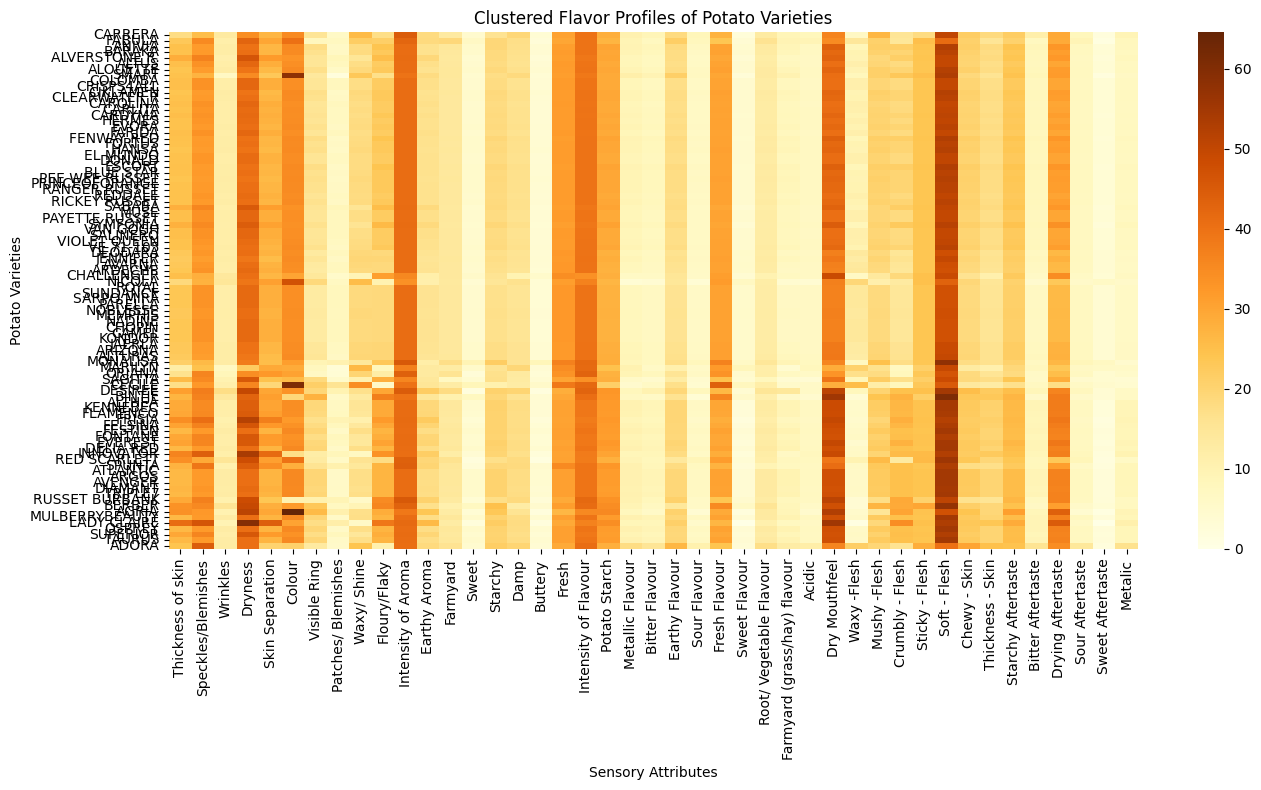

               Cluster
CARRERA              1
FABULA               1
ANIVIA               1
BARAKA               1
ALVERSTONE R.        1
...                ...
LADY CLAIRE          3
OSPREY               3
SUPERIOR             3
TAURUS               3
ADORA                4

[90 rows x 1 columns]


In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


# Standardize data
scaler = StandardScaler()
sensory_scaled = scaler.fit_transform(all_sensory)

# Hierarchical clustering
linkage_matrix = linkage(sensory_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=all_sensory.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Potato Varieties by Flavor")
plt.xlabel("Varieties")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Choose number of clusters here i used 4 cluster
num_clusters = 4
clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
all_sensory['Cluster'] = clusters

# Plot clustered heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(all_sensory.drop(columns=['Cluster']).iloc[np.argsort(clusters)], 
            cmap="YlOrBr", yticklabels=all_sensory.index[np.argsort(clusters)])
plt.title("Clustered Flavor Profiles of Potato Varieties")
plt.xlabel("Sensory Attributes")
plt.ylabel("Potato Varieties")
plt.tight_layout()
plt.show()

# Show each variety’s cluster
cluster_groups = all_sensory[['Cluster']].sort_values('Cluster')
print(cluster_groups)


in the dendogram
Group 1 (left): Varieties like Fenway Red, Escort, Ranger Russet, and Sarpo Mira taste milder and more balanced.
Group 2 (right): Varieties like Innovator, Russet Burbank, and Lady Claire have stronger, more distinctive flavors (like sweet, buttery, or cooked-potato notes).
Special case: Innovator stands out on its own, showing a very unique flavor profile.

in the heatmap, By looking at the clustering, we can see which varieties share similar flavor profiles and which ones stand out as unique. In simple terms, it’s a visual way to group potatoes based on how they taste and feel when eaten.

# Show the distribution of each sensory attribute across all varieties.

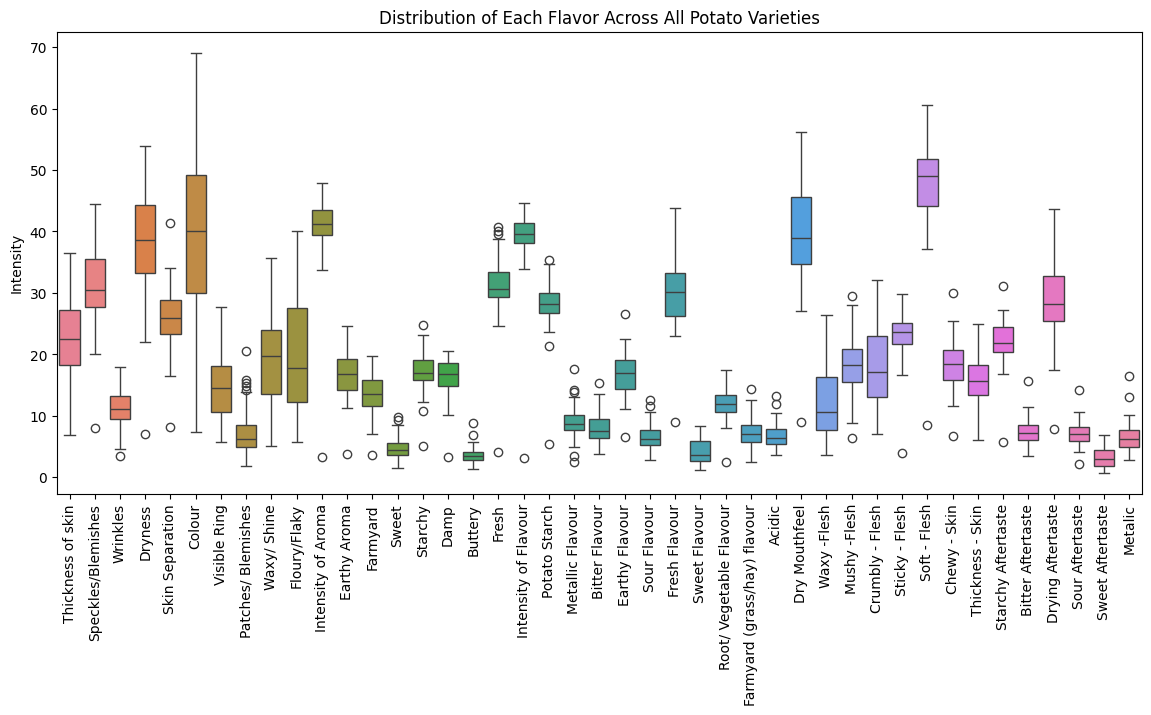

In [22]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=sensory_traits)  
plt.xticks(rotation=90)
plt.title("Distribution of Each Flavor Across All Potato Varieties")
plt.ylabel("Intensity")
plt.show()

the boxplot shows Some potato flavors (like Dryness, Waxy Flesh, and Flavor Intensity) vary a lot between varieties ( some are mild, others really strong).
Others (like Metallic, Sour, and Farmyard) stay pretty similar across all potatoes.
Overall, traits like Dry Mouthfeel and Waxy Flesh are the most dominant, while Sweet Aftertaste and Metallic are generally weak.
The dots show outliers — a few varieties really stand out with unusually strong flavors.

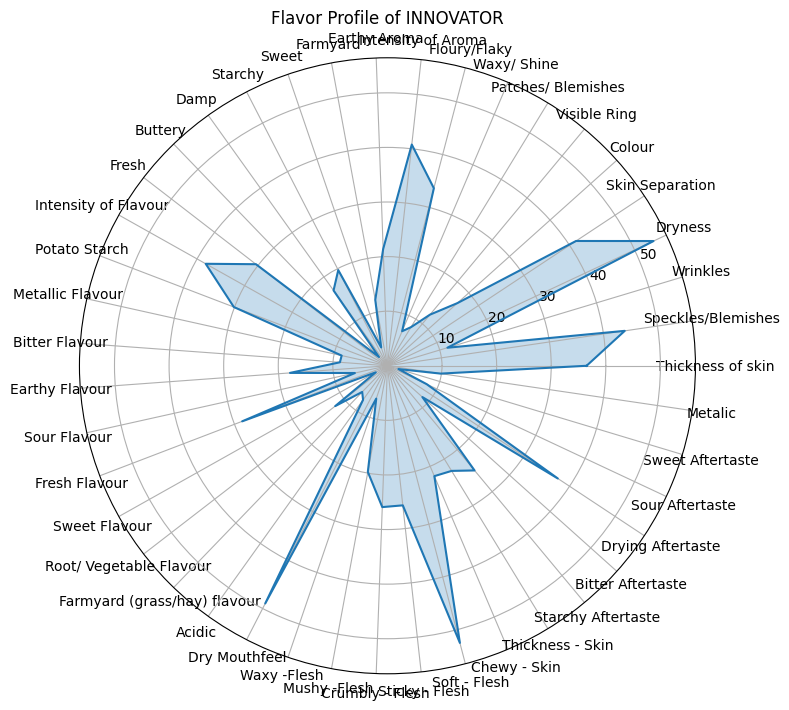

In [23]:


def radar_chart(data, variety_name):
    labels = data.columns
    values = data.loc[variety_name].values
    num_vars = len(labels)
    
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]
    
    plt.figure(figsize=(8,8))
    plt.polar(angles, values)
    plt.fill(angles, values, alpha=0.25)
    plt.xticks(angles[:-1], labels, rotation=90)
    plt.title(f"Flavor Profile of {variety_name}")
    plt.show()

radar_chart(sensory_traits, "INNOVATOR")


This radar chart shows the flavor profile of Innovator potatoes. It’s clear that Innovator is very dry and starchy, with a floury/flaky texture and some waxy flesh. It has little sweetness or metallic taste and only mild buttery or fresh notes. In short, it’s a classic dry, starchy potato — great for mashing or baking.